# Fine tuning BERT for Sentiment Classification task on IMDb Movie Reviews Dataset

Setup(Installs + Imports + GPU check)

Install Dependencies

In [1]:
#Installing dependencies
!pip -q install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

!pip -q install -U transformers datasets scikit-learn matplotlib tqdm
!pip install -U datasets huggingface_hub transformers

#Imports & GPU check
import os, random, math, json
import numpy as np
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, get_linear_schedule_with_warmup)
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

print("PyTorch:", torch.__version__)
print("Transformers:", __import__("transformers").__version__)
print("Datasets:", __import__("datasets").__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("CUDA GPU:", torch.cuda.get_device_name(0))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.1/721.1 kB 16.5 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.19.0
    Uninstalling huggingface_hub-1.19.0:
      Successfully uninstalled huggingface_hub-1.19.0
PyTorch: 2.11.0+cu128
Transformers: 5.12.1
Datasets: 5.0.0
Using device: cuda
CUDA GPU: Tesla T4


Reproducibility utilities

In [2]:
#@title Reproducibility utilities
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    # Extra determinism (slower but repeatable)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)
print("Seed set to", SEED)

Seed set to 42


Hyperparameters

In [3]:
#@title Hyperparameters (edit as needed)
MODEL_NAME = "bert-base-uncased" #@param {type:"string"}
BATCH_SIZE = 16                  #@param {type:"integer"}
EPOCHS = 3                       #@param {type:"integer"}
LR = 2e-5                        #@param {type:"number"}
WEIGHT_DECAY = 0.01              #@param {type:"number"}
WARMUP_RATIO = 0.1               #@param {type:"number"}
MAX_LENGTH = 256                 #@param {type:"integer"}
NUM_WORKERS = 2                  #@param {type:"integer"}
EARLY_STOP_PATIENCE = 2          #@param {type:"integer"}
MAX_GRAD_NORM = 1.0              #@param {type:"number"}

SAVE_DIR = "bert_imdb_best"
os.makedirs(SAVE_DIR, exist_ok=True)

for k, v in list(globals().items()):
    if k in ["MODEL_NAME", "BATCH_SIZE", "EPOCHS", "LR", "WEIGHT_DECAY", "WARMUP_RATIO", "MAX_LENGTH", "NUM_WORKERS"]:
     print(f"{k:>18s} = {v}")

        MODEL_NAME = bert-base-uncased
        BATCH_SIZE = 16
            EPOCHS = 3
                LR = 2e-05
      WEIGHT_DECAY = 0.01
      WARMUP_RATIO = 0.1
        MAX_LENGTH = 256
       NUM_WORKERS = 2


Loading Dataset and Tokenizer

In [5]:
#@title Load IMDb and tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

raw = load_dataset("stanfordnlp/imdb")
print(raw)
print("\nExample train item:\n", raw["train"][0]["text"][:300], "...")

# Split original train into train/valid (90/10)
split = raw["train"].train_test_split(test_size=0.1, seed=SEED)
ds_train, ds_valid = split["train"], split["test"]
ds_test = raw["test"]
print(f"\nSizes: train={len(ds_train)}, valid={len(ds_valid)}, test={len(ds_test)}")

def tokenize_fn(batch):
    # truncation keeps sequences within MAX_LENGTH; padding deferred to collator
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH, padding=False)

ds_train = ds_train.map(tokenize_fn, batched=True, remove_columns=["text"])
ds_valid = ds_valid.map(tokenize_fn, batched=True, remove_columns=["text"])
ds_test = ds_test.map(tokenize_fn, batched=True, remove_columns=["text"])

cols = ["input_ids", "attention_mask", "label"]
ds_train.set_format(type="torch", columns=cols)
ds_valid.set_format(type="torch", columns=cols)
ds_test.set_format(type="torch", columns=cols)

collator = DataCollatorWithPadding(tokenizer=tokenizer, pad_to_multiple_of=None)

dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,
                      collate_fn=collator, num_workers=NUM_WORKERS, pin_memory=True)
dl_valid = DataLoader(ds_valid, batch_size=BATCH_SIZE, shuffle=False,
                      collate_fn=collator, num_workers=NUM_WORKERS, pin_memory=True)
dl_test = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False,
                     collate_fn=collator, num_workers=NUM_WORKERS, pin_memory=True)

print("\nDataloaders ready ✓")

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

...

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Example train item:
 I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h ...

Sizes: train=22500, valid=2500, test=25000


Map:   0%|          | 0/22500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]


Dataloaders ready ✓


In [6]:
raw['train'][0]

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

In [7]:
ds_train['label'][0]

tensor(0)

Loading BERT with classification Head

In [8]:
#@title Load BERT with classification head
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.to(device)
tokenizer.save_pretrained(SAVE_DIR) # keep tokenizer with best model
print("Model loaded and moved to", device)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded and moved to cuda


Eval Function (loss, accuracy, macro-F1 + preds/labels)

In [9]:
@torch.no_grad()
def evaluate(model, dataloader, device):
    model.eval()
    losses, preds_all, labels_all = [], [], []

    for batch in dataloader:
        batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}
        outputs = model(**batch) # works if batch has 'labels' for loss
        loss = outputs.loss
        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1)

        losses.append(loss.item())
        # handle either key
        label_key = "labels" if "labels" in batch else "label"
        labels_all.extend(batch[label_key].cpu().tolist())
        preds_all.extend(preds.cpu().tolist())

    import numpy as np
    from sklearn.metrics import accuracy_score, f1_score
    loss_mean = float(np.mean(losses)) if losses else 0.0
    acc = accuracy_score(labels_all, preds_all)
    f1 = f1_score(labels_all, preds_all, average="macro")
    return {"loss": loss_mean, "accuracy": acc, "macro_f1": f1,
            "preds": preds_all, "labels": labels_all}

Early Callback

In [10]:
#@title EarlyStopping callback (metric-agnostic, with checkpointing)
import math
from pathlib import Path

class EarlyStopping:
    """
    Early-stopping utility.
    - monitor: metric to monitor ("loss" smaller-is-better or any 'higher_is_better'=False)
    - patience: epochs to wait without improvement before stopping
    - min_delta: minimal change to qualify as an improvement (avoid tiny fluctuations)
    - mode: "min" (e.g., val loss) or "max" (e.g., val F1)
    - ckpt_dir: where to save the best model via model.save_pretrained(...)
    """
    def __init__(self, patience=2, min_delta=0.0, mode="min", ckpt_dir="bert_imdb_best"):
        assert mode in ("min", "max")
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.best = math.inf if mode == "min" else -math.inf
        self.num_bad_epochs = 0
        self.should_stop = False
        self.best_epoch = None
        self.ckpt_dir = Path(ckpt_dir)
        self.ckpt_dir.mkdir(parents=True, exist_ok=True)

    def _is_improvement(self, current):
        if self.mode == "min":
            return current < (self.best - self.min_delta)
        else:
            return current > (self.best + self.min_delta)

    def step(self, current_value, epoch_idx, model=None):
        """
        Call at the end of each epoch with the monitored value.
        If improvement: reset counter, save best, and optionally checkpoint.
        If no improvement: increase counter, set should_stop when patience exceeded.
        """
        if self._is_improvement(current_value):
            self.best = current_value
            self.num_bad_epochs = 0
            self.best_epoch = epoch_idx
            if model is not None:
                model.save_pretrained(str(self.ckpt_dir))
        else:
            self.num_bad_epochs += 1
            if self.num_bad_epochs >= self.patience:
                self.should_stop = True

In [15]:
#@title Training loop (now using EarlyStopping callback)
def train(model, train_loader, valid_loader, device,
          epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY, warmup_ratio=WARMUP_RATIO,
          max_grad_norm=MAX_GRAD_NORM, early_stopping_patience=EARLY_STOP_PATIENCE,
          save_dir=SAVE_DIR, monitor_mode="min", min_delta=0.0):

    total_steps = len(train_loader) * epochs
    warmup_steps = int(total_steps * warmup_ratio)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
    )
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

    es = EarlyStopping(patience=early_stopping_patience, min_delta=min_delta,
                       mode=monitor_mode, ckpt_dir=save_dir)

    history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}
    stopped_epoch = None

    for ep in range(1, epochs + 1):
        model.train()
        running_loss = 0.0

        pbar = tqdm(train_loader, desc=f"Epoch {ep}/{epochs}")
        for step, batch in enumerate(pbar, start=1):
            batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}

            with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                outputs = model(**batch)
                loss = outputs.loss

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()

            running_loss += loss.item()
            avg_loss = running_loss / step
            pbar.set_postfix({"train_loss": f"{avg_loss:.4f}", "lr": f"{scheduler.get_last_lr()[0]:.2e}"})

        # ---- Validation & early-stopping step ----
        val_metrics = evaluate(model, valid_loader, device)
        val_loss = val_metrics["loss"]

        history["train_loss"].append(avg_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_metrics["accuracy"])
        history["val_f1"].append(val_metrics["macro_f1"])

        print(f"[Epoch {ep}] TrainLoss={avg_loss:.4f} | "
              f"ValLoss={val_loss:.4f} | ValAcc={val_metrics['accuracy']:.4f} | "
              f"ValMacroF1={val_metrics['macro_f1']:.4f}")

        # Monitor validation loss by default (mode='min')
        monitor_value = val_loss if monitor_mode == "min" else val_metrics["macro_f1"]
        es.step(monitor_value, epoch_idx=ep, model=model)

        if es.best_epoch == ep:
            print(f"  └── New best @ epoch {ep}. Saved to '{save_dir}'")
        else:
            print(f"  └── No improvement. Early stopping counter: {es.num_bad_epochs}/{es.patience}")
            if es.should_stop:
                print(f"Early stopping triggered at epoch {ep}. Training stopped.")
                stopped_epoch = ep
                break

    return history, es.best_epoch, stopped_epoch

In [12]:
#@title Check and summarize trainable vs frozen parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params
trainable_percent = 100.0 * trainable_params / total_params

print("--- Model Parameter Summary ---")
print(f"Total parameters  : {total_params:,}")
print(f"Trainable params  : {trainable_params:,}")
print(f"Frozen params     : {frozen_params:,}")
print(f"Trainable fraction : {trainable_percent:.4f}%\n")

print("Trainable layers:")
for n, p in model.named_parameters():
    if p.requires_grad:
        print(f"  {n:<35s} {p.numel():,}")

--- Model Parameter Summary ---
Total parameters  : 109,483,778
Trainable params  : 109,483,778
Frozen params     : 0
Trainable fraction : 100.0000%

Trainable layers:
  bert.embeddings.word_embeddings.weight 23,440,896
  bert.embeddings.position_embeddings.weight 393,216
  bert.embeddings.token_type_embeddings.weight 1,536
  bert.embeddings.LayerNorm.weight    768
  bert.embeddings.LayerNorm.bias      768
  bert.encoder.layer.0.attention.self.query.weight 589,824
  bert.encoder.layer.0.attention.self.query.bias 768
  bert.encoder.layer.0.attention.self.key.weight 589,824
  bert.encoder.layer.0.attention.self.key.bias 768
  bert.encoder.layer.0.attention.self.value.weight 589,824
  bert.encoder.layer.0.attention.self.value.bias 768
  bert.encoder.layer.0.attention.output.dense.weight 589,824
  bert.encoder.layer.0.attention.output.dense.bias 768
  bert.encoder.layer.0.attention.output.LayerNorm.weight 768
  bert.encoder.layer.0.attention.output.LayerNorm.bias 768
  bert.encoder.layer.0

In [16]:
#@title Train with early stopping
history, best_epoch, stopped_epoch = train(
    model, dl_train, dl_valid, device,  # <-- Change ds_train to dl_train here
    epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY, warmup_ratio=WARMUP_RATIO,
    early_stopping_patience=EARLY_STOP_PATIENCE, save_dir=SAVE_DIR,
    monitor_mode="min",
    min_delta=0.0
)

/tmp/ipykernel_4698/1023905844.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


Epoch 1/3:   0%|          | 0/1407 [00:00<?, ?it/s]

/tmp/ipykernel_4698/1023905844.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


[Epoch 1] TrainLoss=0.3236 | ValLoss=0.2357 | ValAcc=0.9120 | ValMacroF1=0.9119


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

/tmp/ipykernel_4698/1023905844.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


[Epoch 2] TrainLoss=0.1672 | ValLoss=0.3084 | ValAcc=0.9136 | ValMacroF1=0.9136
  └── No improvement. Early stopping counter: 1/2


Epoch 3/3:   0%|          | 0/1407 [00:00<?, ?it/s]

/tmp/ipykernel_4698/1023905844.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


[Epoch 3] TrainLoss=0.0855 | ValLoss=0.3675 | ValAcc=0.9164 | ValMacroF1=0.9164
  └── No improvement. Early stopping counter: 2/2
Early stopping triggered at epoch 3. Training stopped.


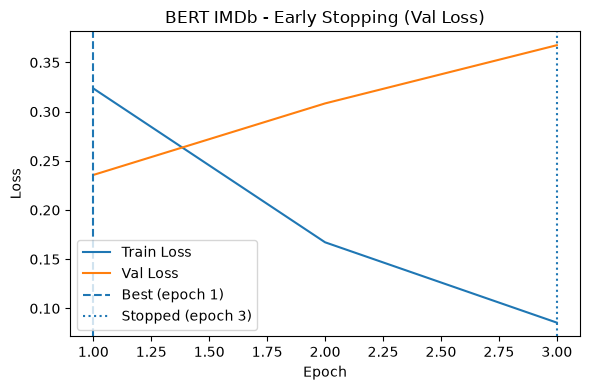

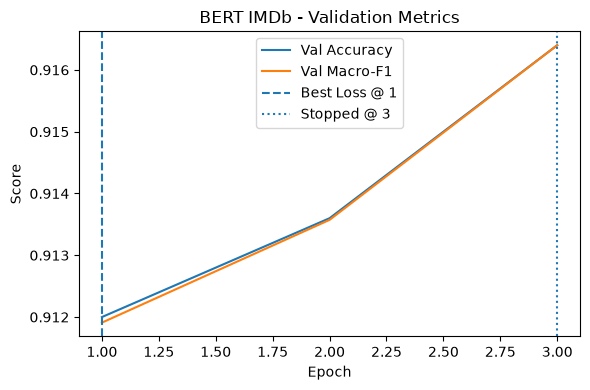

In [17]:
#@title Annotated training curves with Early Stopping markers
import numpy as np
import matplotlib.pyplot as plt

epochs_arr = np.arange(1, len(history["val_loss"]) + 1)

# Loss curves
plt.figure(figsize=(6, 4))
plt.plot(epochs_arr, history["train_loss"], label="Train Loss")
plt.plot(epochs_arr, history["val_loss"], label="Val Loss")
if best_epoch is not None:
    plt.axvline(best_epoch, linestyle="--", label=f"Best (epoch {best_epoch})")
if stopped_epoch is not None:
    plt.axvline(stopped_epoch, linestyle=":", label=f"Stopped (epoch {stopped_epoch})")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BERT IMDb - Early Stopping (Val Loss)")
plt.legend()
plt.tight_layout()
plt.show()

# Validation metrics for reference
plt.figure(figsize=(6, 4))
plt.plot(epochs_arr, history["val_acc"], label="Val Accuracy")
plt.plot(epochs_arr, history["val_f1"], label="Val Macro-F1")
if best_epoch is not None:
    plt.axvline(best_epoch, linestyle="--", label=f"Best Loss @ {best_epoch}")
if stopped_epoch is not None:
    plt.axvline(stopped_epoch, linestyle=":", label=f"Stopped @ {stopped_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("BERT IMDb - Validation Metrics")
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
#@title Final evaluation on test set
best_model = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR).to(device)

test_metrics = evaluate(best_model, dl_test, device)
print("\n=== TEST RESULTS (Best Checkpoint) ===")
print(f"Test Loss        : {test_metrics['loss']:.4f}")
print(f"Test Accuracy    : {test_metrics['accuracy']:.4f}")
print(f"Test Macro-F1    : {test_metrics['macro_f1']:.4f}")

print("\nClassification Report (0=neg, 1=pos):")
print(classification_report(test_metrics["labels"], test_metrics["preds"],
                            target_names=["neg", "pos"], digits=4))

cm = confusion_matrix(test_metrics["labels"], test_metrics["preds"], labels=[0,1])
print("Confusion Matrix (rows=true, cols=pred):\n", cm)

# Save for later (optional)
np.save(os.path.join(SAVE_DIR, "confusion_matrix.npy"), cm)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


=== TEST RESULTS (Best Checkpoint) ===
Test Loss        : 0.2226
Test Accuracy    : 0.9135
Test Macro-F1    : 0.9134

Classification Report (0=neg, 1=pos):
              precision    recall  f1-score   support

         neg     0.9438    0.8794    0.9105     12500
         pos     0.8871    0.9476    0.9164     12500

    accuracy                         0.9135     25000
   macro avg     0.9155    0.9135    0.9134     25000
weighted avg     0.9155    0.9135    0.9134     25000

Confusion Matrix (rows=true, cols=pred):
 [[10993  1507]
 [  655 11845]]


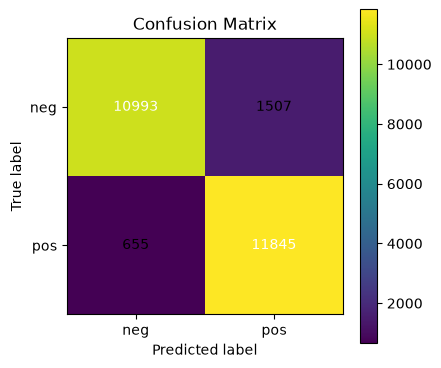

In [19]:
#@title Plot confusion matrix
def plot_confusion_matrix(cm, class_names=["neg", "pos"]):
    fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(cm, interpolation='nearest')
    ax.figure.colorbar(im, ax=ax)

    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=class_names, yticklabels=class_names,
           ylabel='True label', xlabel='Predicted label',
           title='Confusion Matrix')

    # Annotate cells
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm)

In [20]:
# Function to compare weights and identify changes
def compare_weights(original, fine_tuned):
    changes_detected = False
    for name, param in fine_tuned.named_parameters():
        if name in original:
            # Check if weights are different
            if not torch.equal(param.data, original[name].data):
                changes_detected = True
                print(f"Weights changed for layer: {name}")
        else:
            print(f"Layer {name} not found in the original model.")

    if not changes_detected:
        print("No changes in weights detected.")
    else:
        print("Weight changes were detected after fine-tuning.")

In [21]:
import torch.nn as nn

original_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

original_model.to(device)

original_model.eval() # Set to evaluation mode to freeze weights

# Clone the weights of the original model for comparison
original_weights = {name: param.clone() for name, param in original_model.named_parameters()}

model.eval()


# Compare the weights of the original and fine-tuned models
compare_weights(original_weights, model)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Weights changed for layer: bert.embeddings.word_embeddings.weight
Weights changed for layer: bert.embeddings.position_embeddings.weight
Weights changed for layer: bert.embeddings.token_type_embeddings.weight
Weights changed for layer: bert.embeddings.LayerNorm.weight
Weights changed for layer: bert.embeddings.LayerNorm.bias
Weights changed for layer: bert.encoder.layer.0.attention.self.query.weight
Weights changed for layer: bert.encoder.layer.0.attention.self.query.bias
Weights changed for layer: bert.encoder.layer.0.attention.self.key.weight
Weights changed for layer: bert.encoder.layer.0.attention.self.key.bias
Weights changed for layer: bert.encoder.layer.0.attention.self.value.weight
Weights changed for layer: bert.encoder.layer.0.attention.self.value.bias
Weights changed for layer: bert.encoder.layer.0.attention.output.dense.weight
Weights changed for layer: bert.encoder.layer.0.attention.output.dense.bias
Weights changed for layer: bert.encoder.layer.0.attention.output.LayerNorm

In [22]:
#@title Freeze all BERT layers except classifier
for name, param in original_model.named_parameters():
    if not name.startswith("classifier"): # "classifier" is the head module
        param.requires_grad = False      # freeze backbone
    else:
        param.requires_grad = True       # keep classifier trainable

# Verify which layers are trainable
trainable = [n for n, p in original_model.named_parameters() if p.requires_grad]
print(f"Trainable parameters: {len(trainable)} layers -> {trainable}")
print(f"Total trainable params: {sum(p.numel() for p in original_model.parameters() if p.requires_grad):,}")

Trainable parameters: 2 layers -> ['classifier.weight', 'classifier.bias']
Total trainable params: 1,538


In [23]:
#@title Check and summarize trainable vs frozen parameters
total_params = sum(p.numel() for p in original_model.parameters())
trainable_params = sum(p.numel() for p in original_model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params
trainable_percent = 100.0 * trainable_params / total_params

print("--- Model Parameter Summary ---")
print(f"Total parameters  : {total_params:,}")
print(f"Trainable params  : {trainable_params:,}")
print(f"Frozen params     : {frozen_params:,}")
print(f"Trainable fraction : {trainable_percent:.4f}%\n")

print("Trainable layers:")
for n, p in original_model.named_parameters():
    if p.requires_grad:
        print(f"  {n:<35s} {p.numel():,}")

--- Model Parameter Summary ---
Total parameters  : 109,483,778
Trainable params  : 1,538
Frozen params     : 109,482,240
Trainable fraction : 0.0014%

Trainable layers:
  classifier.weight                   1,536
  classifier.bias                     2
